##💳 AdaBoost vs XGBoost — Kredi Kartı Dolandırıcılık Tespiti
Veri seti: Credit Card Fraud Detection — 284.807 işlem, bunların sadece 492'si (%0.17) dolandırıcılık.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification, load_breast_cancer

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve

from sklearn.ensemble import AdaBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

import xgboost as xgb
import time

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'   XGBoost versiyonu: {xgb.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi!
   XGBoost versiyonu: 3.4.1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Veri Analitiği/creditcard.csv')  # kopyaladığın gerçek yolu buraya yapıştır
print(df.shape)

(284807, 31)


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
print('🔍 Eksik değer sayısı (toplam) :', df.isnull().sum().sum())
print('🔍 Tekrarlı satır sayısı       :', df.duplicated().sum())

🔍 Eksik değer sayısı (toplam) : 0
🔍 Tekrarlı satır sayısı       : 1081


In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

print('📋 Veri Seti Bilgileri')
print("-" * 40)
print(f'Özellik sayısı  : {X.shape[1]}')
print(f'Örnek sayısı    : {X.shape[0]}')
print("Hedef Değişken Dağılımı:")
print("0: Normal İşlem | 1: Dolandırıcılık")
print(y.value_counts())
print(f'Dolandırıcılık oranı: %{100 * y.mean():.3f}')
print("-" * 40)

📋 Veri Seti Bilgileri
----------------------------------------
Özellik sayısı  : 30
Örnek sayısı    : 284807
Hedef Değişken Dağılımı:
0: Normal İşlem | 1: Dolandırıcılık
Class
0    284315
1       492
Name: count, dtype: int64
Dolandırıcılık oranı: %0.173
----------------------------------------


0: Normal (Güvenli) İşlem

1: Dolandırıcılık (Fraud) İşlemi

`Class`, veri setindeki "sonuç" / "etiket" sütunudur.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Eğitim seti: {X_train.shape[0]} örnek')
print(f'Test seti  : {X_test.shape[0]} örnek')
print(f'Eğitim setindeki dolandırıcılık sayısı: {(y_train == 1).sum()}')
print(f'Test setindeki dolandırıcılık sayısı  : {(y_test == 1).sum()}')

X.head()

Eğitim seti: 227845 örnek
Test seti  : 56962 örnek
Eğitim setindeki dolandırıcılık sayısı: 394
Test setindeki dolandırıcılık sayısı  : 98


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


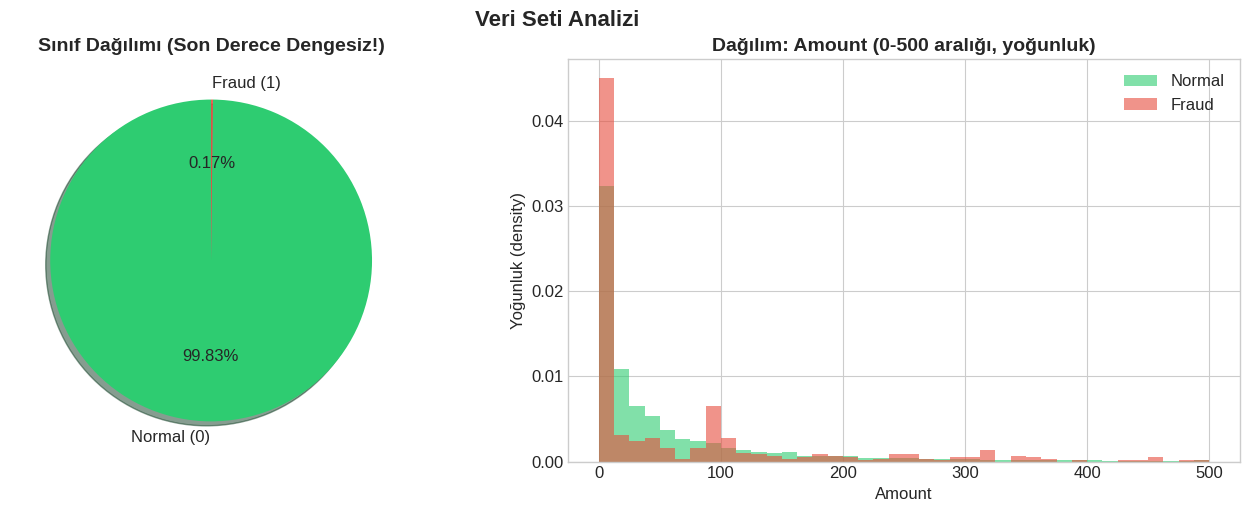

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = y.value_counts()
labels = ['Normal (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)
axes[0].set_title('Sınıf Dağılımı (Son Derece Dengesiz!)', fontsize=14, fontweight='bold')

feature_to_plot = 'Amount'
axes[1].hist(X[feature_to_plot][y == 0], bins=40, range=(0, 500), alpha=0.6,
             density=True, label='Normal', color='#2ecc71')
axes[1].hist(X[feature_to_plot][y == 1], bins=40, range=(0, 500), alpha=0.6,
             density=True, label='Fraud', color='#e74c3c')
axes[1].set_title(f'Dağılım: {feature_to_plot} (0-500 aralığı, yoğunluk)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(feature_to_plot)
axes[1].set_ylabel('Yoğunluk (density)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Veri Seti Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 🔴 AdaBoost Modeli

In [11]:
print('ADABOOST MODELİ EĞİTİLİYOR')
print('='*45)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42)

start = time.time()
ada_model.fit(X_train, y_train)
ada_time = time.time() - start

ada_pred = ada_model.predict(X_test)

ada_prob = ada_model.predict_proba(X_test)[:, 1]

ada_accuracy = accuracy_score(y_test, ada_pred)
ada_precision = precision_score(y_test, ada_pred)
ada_f1 = f1_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)
ada_auc    = roc_auc_score(y_test, ada_prob)

print(f'✅ Eğitim Süresi   : {ada_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {ada_accuracy:.4f}  ({ada_accuracy*100:.2f}%)')
print(f'📊 AUC-ROC         : {ada_auc:.4f}')
print(f'📊 F1 Skoru        : {ada_f1:.4f}')
print(f'📊 Precision       : {ada_precision:.4f}')
print(f'📊 Recall          : {ada_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, ada_pred, target_names=['Normal (0)', 'Fraud (1)']))

ADABOOST MODELİ EĞİTİLİYOR
✅ Eğitim Süresi   : 235.2795 sn
📊 Doğruluk (Acc)  : 0.9990  (99.90%)
📊 AUC-ROC         : 0.9709
📊 F1 Skoru        : 0.6707
📊 Precision       : 0.8116
📊 Recall          : 0.5714

📋 Detaylı Rapor:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.81      0.57      0.67        98

    accuracy                           1.00     56962
   macro avg       0.91      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



## 📈 `n_estimators` Etkisi

AdaBoost'ta zayıf öğrenici sayısı arttıkça model eğitim verisine daha agresif şekilde uyum sağlar; bu belirli bir noktadan sonra **overfitting** riski taşır.


Alt örneklemdeki dolandırıcılık sayısı: 35 / 20000


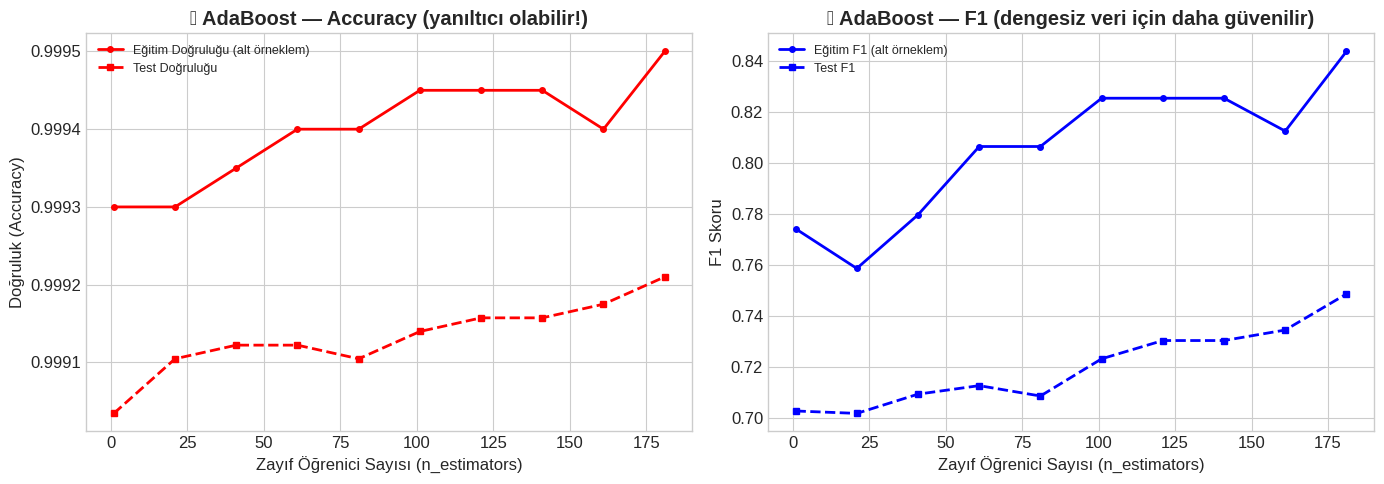

In [12]:
SUBSAMPLE_SIZE = 20000
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)
print(f'Alt örneklemdeki dolandırıcılık sayısı: {(y_sub == 1).sum()} / {SUBSAMPLE_SIZE}')

n_estimators_range = range(1, 201, 20)
ada_train_scores, ada_train_f1 = [], []
ada_test_scores, ada_test_f1 = [], []

for n in n_estimators_range:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        learning_rate=0.1,
        algorithm='SAMME',
        random_state=42
    )
    m.fit(X_sub, y_sub)

    train_pred = m.predict(X_sub)
    test_pred = m.predict(X_test)

    ada_train_scores.append(accuracy_score(y_sub, train_pred))
    ada_test_scores.append(accuracy_score(y_test, test_pred))
    ada_train_f1.append(f1_score(y_sub, train_pred))
    ada_test_f1.append(f1_score(y_test, test_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(n_estimators_range), ada_train_scores, 'r-o', markersize=4,
             label='Eğitim Doğruluğu (alt örneklem)', linewidth=2)
axes[0].plot(list(n_estimators_range), ada_test_scores, 'r--s', markersize=4,
             label='Test Doğruluğu', linewidth=2)
axes[0].set_xlabel('Zayıf Öğrenici Sayısı (n_estimators)')
axes[0].set_ylabel('Doğruluk (Accuracy)')
axes[0].set_title('🔴 AdaBoost — Accuracy (yanıltıcı olabilir!)', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(list(n_estimators_range), ada_train_f1, 'b-o', markersize=4,
             label='Eğitim F1 (alt örneklem)', linewidth=2)
axes[1].plot(list(n_estimators_range), ada_test_f1, 'b--s', markersize=4,
             label='Test F1', linewidth=2)
axes[1].set_xlabel('Zayıf Öğrenici Sayısı (n_estimators)')
axes[1].set_ylabel('F1 Skoru')
axes[1].set_title('🔴 AdaBoost — F1 (dengesiz veri için daha güvenilir)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 🟢 XGBoost Modeli

In [14]:
print('🟢 XGBOOST MODELİ EĞİTİLİYOR...')
print('='*45)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print(f'✅ Eğitim Süresi   : {xgb_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {xgb_accuracy:.4f}  ({xgb_accuracy*100:.2f}%)')
print(f'📊 AUC-ROC         : {xgb_auc:.4f}')
print(f'📊 F1 Skoru        : {xgb_f1:.4f}')
print(f'📊 Precision       : {xgb_precision:.4f}')
print(f'📊 Recall          : {xgb_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, xgb_pred, target_names=['Normal (0)', 'Fraud (1)']))

🟢 XGBOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 4.0639 sn
📊 Doğruluk (Acc)  : 0.9995  (99.95%)
📊 AUC-ROC         : 0.9786
📊 F1 Skoru        : 0.8427
📊 Precision       : 0.9375
📊 Recall          : 0.7653

📋 Detaylı Rapor:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.94      0.77      0.84        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



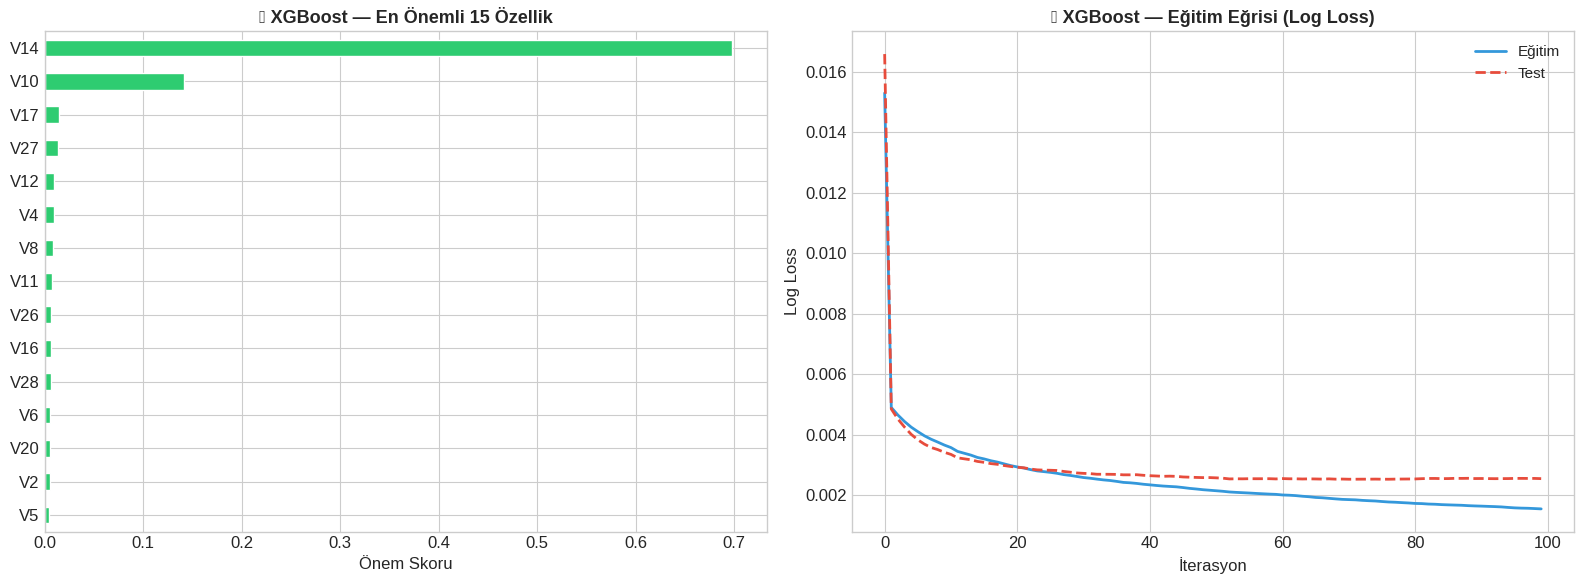

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

feat_importance.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('🟢 XGBoost — En Önemli 15 Özellik', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Önem Skoru')

results = xgb_model.evals_result()

axes[1].plot(results['validation_0']['logloss'], label='Eğitim', color='#3498db', linewidth=2)
axes[1].plot(results['validation_1']['logloss'], label='Test', color='#e74c3c', linewidth=2, linestyle='--')

axes[1].set_title('🟢 XGBoost — Eğitim Eğrisi (Log Loss)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('İterasyon')
axes[1].set_ylabel('Log Loss')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## ⚖️ Kapsamlı Karşılaştırma

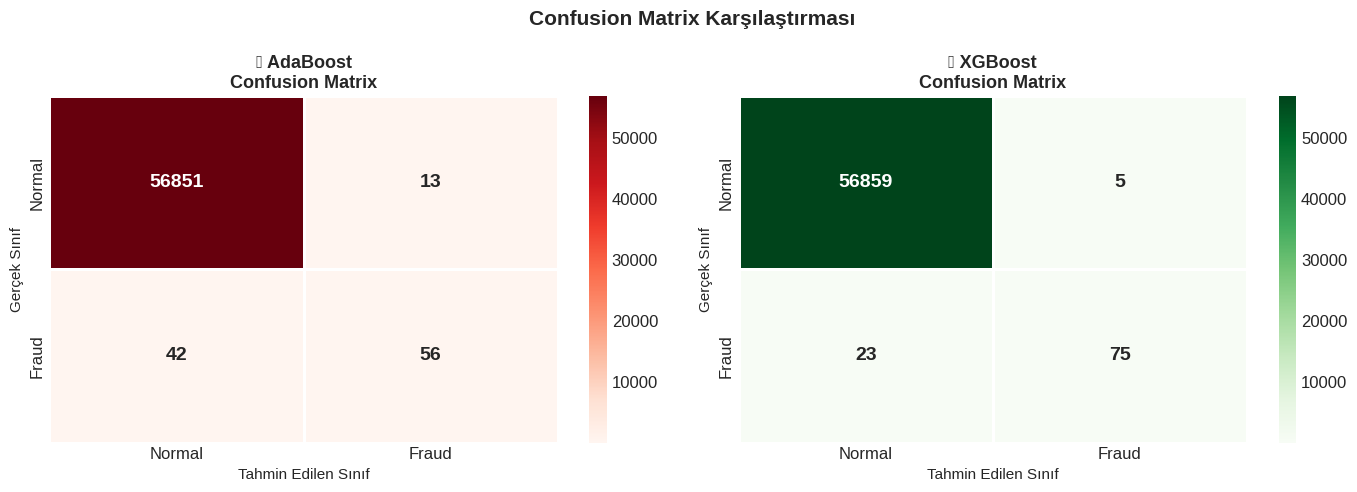

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, color in zip(
    axes,
    [ada_pred, xgb_pred],
    ['🔴 AdaBoost', '🟢 XGBoost'],
    ['Reds', 'Greens']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        ax=ax,
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud'],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Gerçek Sınıf', fontsize=11)
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

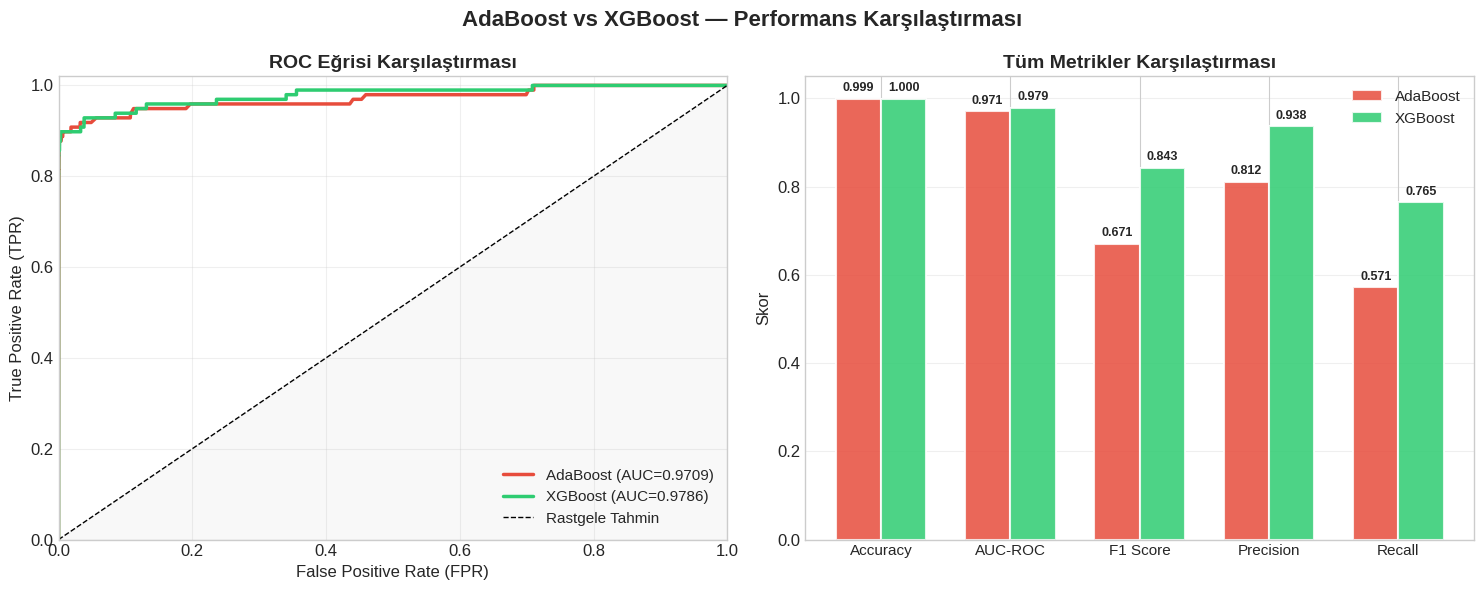

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for prob, label, color, acc, auc in [
    (ada_prob, 'AdaBoost', '#e74c3c', ada_accuracy, ada_auc),
    (xgb_prob, 'XGBoost',  '#2ecc71', xgb_accuracy, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

metrics = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
ada_scores = [ada_accuracy, ada_auc, ada_f1, ada_precision, ada_recall]
xgb_scores = [xgb_accuracy, xgb_auc, xgb_f1, xgb_precision, xgb_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, ada_scores, width, label='AdaBoost',
                     color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, xgb_scores, width, label='XGBoost',
                     color='#2ecc71', alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Skor', fontsize=12)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('AdaBoost vs XGBoost — Performans Karşılaştırması',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔄 Çapraz Doğrulama (Cross Validation)



🔄 Cross Validation Yapılıyor (alt örneklem üzerinde, cv=3, scoring=f1)...
Alt örneklemdeki dolandırıcılık sayısı: 35 / 20000
🔴 AdaBoost  CV F1 Scores: [0.8182 0.7619 0.5882]
   Ortalama: 0.7228 ± 0.0979

🟢 XGBoost   CV F1 Scores: [0.9167 0.8182 0.8   ]
   Ortalama: 0.8449 ± 0.0513


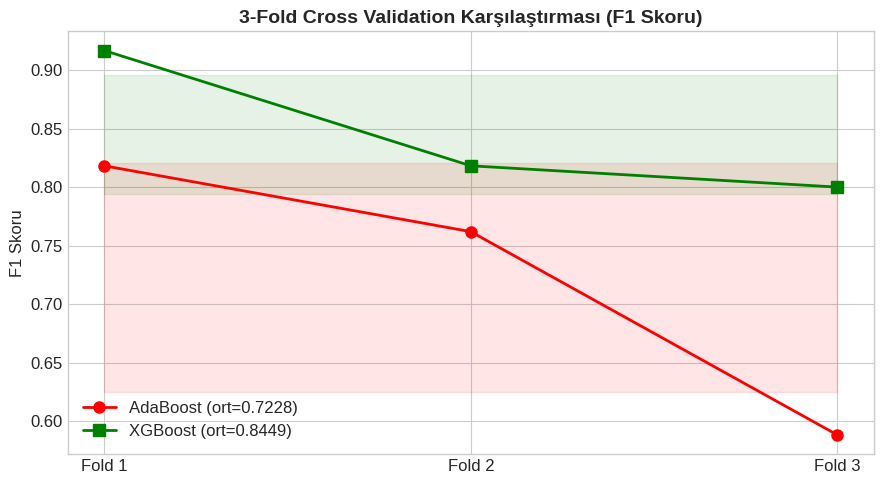

In [18]:
print('🔄 Cross Validation Yapılıyor (alt örneklem üzerinde, cv=3, scoring=f1)...')
print('='*55)

CV_SAMPLE_SIZE = 20000
X_cv, _, y_cv, _ = train_test_split(
    X, y,
    train_size=CV_SAMPLE_SIZE,
    stratify=y,
    random_state=42
)
print(f'Alt örneklemdeki dolandırıcılık sayısı: {(y_cv == 1).sum()} / {CV_SAMPLE_SIZE}')

ada_cv = cross_val_score(ada_model, X_cv, y_cv, cv=3, scoring='f1', n_jobs=-1)
xgb_cv = cross_val_score(xgb_model, X_cv, y_cv, cv=3, scoring='f1', n_jobs=-1)

print(f'🔴 AdaBoost  CV F1 Scores: {ada_cv.round(4)}')
print(f'   Ortalama: {ada_cv.mean():.4f} ± {ada_cv.std():.4f}')
print()
print(f'🟢 XGBoost   CV F1 Scores: {xgb_cv.round(4)}')
print(f'   Ortalama: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
folds = [f'Fold {i+1}' for i in range(3)]
x = np.arange(3)

ax.plot(x, ada_cv, 'r-o', markersize=8, linewidth=2, label=f'AdaBoost (ort={ada_cv.mean():.4f})')
ax.plot(x, xgb_cv, 'g-s', markersize=8, linewidth=2, label=f'XGBoost (ort={xgb_cv.mean():.4f})')

ax.fill_between(x, ada_cv.mean() - ada_cv.std(), ada_cv.mean() + ada_cv.std(), alpha=0.1, color='red')
ax.fill_between(x, xgb_cv.mean() - xgb_cv.std(), xgb_cv.mean() + xgb_cv.std(), alpha=0.1, color='green')

ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylabel('F1 Skoru', fontsize=12)
ax.set_title('3-Fold Cross Validation Karşılaştırması (F1 Skoru)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### ⏱️ Veri Boyutuna Göre Eğitim Süresi



n=   1000  |  AdaBoost:   0.01 sn  |  XGBoost:   0.07 sn
n=   5000  |  AdaBoost:   2.94 sn  |  XGBoost:   0.60 sn
n=  20000  |  AdaBoost:  11.52 sn  |  XGBoost:   1.25 sn
n=  50000  |  AdaBoost:  34.93 sn  |  XGBoost:   0.85 sn
n= 100000  |  AdaBoost:  79.12 sn  |  XGBoost:   1.22 sn
n= 227845  |  AdaBoost: 233.05 sn  |  XGBoost:   4.41 sn


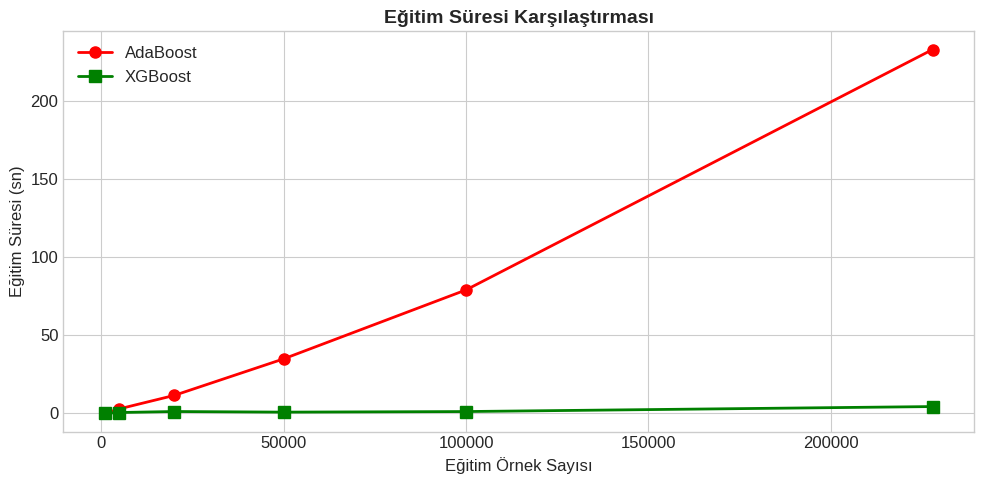


Tam veri (n=227845) eğitim süreleri:
  🔴 AdaBoost : 235.2795 sn
  🟢 XGBoost  : 4.0639 sn


In [19]:
sizes = [1000, 5000, 20000, 50000, 100000, len(X_train)]
ada_times_list = []
xgb_times_list = []

for s in sizes:
    Xs = X_train.iloc[:s]
    ys = y_train.iloc[:s]

    m1 = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=0.1, algorithm='SAMME', random_state=42
    )
    t1 = time.time()
    m1.fit(Xs, ys)
    ada_times_list.append(time.time() - t1)

    m2 = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    t2 = time.time()
    m2.fit(Xs, ys)
    xgb_times_list.append(time.time() - t2)

    print(f'n={s:>7}  |  AdaBoost: {ada_times_list[-1]:6.2f} sn  |  XGBoost: {xgb_times_list[-1]:6.2f} sn')

plt.figure(figsize=(10, 5))
plt.plot(sizes, ada_times_list, 'r-o', markersize=8, linewidth=2, label='AdaBoost')
plt.plot(sizes, xgb_times_list, 'g-s', markersize=8, linewidth=2, label='XGBoost')
plt.xlabel('Eğitim Örnek Sayısı', fontsize=12)
plt.ylabel('Eğitim Süresi (sn)', fontsize=12)
plt.title('Eğitim Süresi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nTam veri (n={len(X_train)}) eğitim süreleri:')
print(f'  🔴 AdaBoost : {ada_time:.4f} sn')
print(f'  🟢 XGBoost  : {xgb_time:.4f} sn')

## 📋 Nihai Sonuç Tablosu

In [20]:
from sklearn.metrics import average_precision_score

ada_ap = average_precision_score(y_test, ada_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)

results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'AUC-PR (Average Precision)', 'F1 Score',
               'Precision', 'Recall', 'CV F1 Ortalama', 'CV F1 Std', 'Eğitim Süresi (sn)'],
    'AdaBoost 🔴': [
        f'{ada_accuracy:.4f}', f'{ada_auc:.4f}', f'{ada_ap:.4f}', f'{ada_f1:.4f}',
        f'{ada_precision:.4f}', f'{ada_recall:.4f}',
        f'{ada_cv.mean():.4f}', f'{ada_cv.std():.4f}',
        f'{ada_time:.4f}'
    ],
    'XGBoost 🟢': [
        f'{xgb_accuracy:.4f}', f'{xgb_auc:.4f}', f'{xgb_ap:.4f}', f'{xgb_f1:.4f}',
        f'{xgb_precision:.4f}', f'{xgb_recall:.4f}',
        f'{xgb_cv.mean():.4f}', f'{xgb_cv.std():.4f}',
        f'{xgb_time:.4f}'
    ],
    'Kazanan': [
        '🟢 XGBoost' if xgb_accuracy  >= ada_accuracy  else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_auc       >= ada_auc       else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_ap        >= ada_ap        else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_f1        >= ada_f1        else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_precision >= ada_precision else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_recall    >= ada_recall    else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.mean() >= ada_cv.mean() else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.std()  <= ada_cv.std()  else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_time      <= ada_time      else '🔴 AdaBoost'
    ]
})

print('\n' + '='*70)
print('     📊 ADABOOST vs XGBOOST — KREDİ KARTI DOLANDIRICILIK TESPİTİ')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

xgb_wins = sum(1 for k in results_df['Kazanan'] if 'XGBoost' in k)
ada_wins = sum(1 for k in results_df['Kazanan'] if 'AdaBoost' in k)
print(f'\n🏆 GENEL SONUÇ:')
print(f'   🟢 XGBoost kazandı  : {xgb_wins}/{len(results_df)} kategoride')
print(f'   🔴 AdaBoost kazandı : {ada_wins}/{len(results_df)} kategoride')


     📊 ADABOOST vs XGBOOST — KREDİ KARTI DOLANDIRICILIK TESPİTİ
                    Metrik AdaBoost 🔴 XGBoost 🟢   Kazanan
                  Accuracy     0.9990    0.9995 🟢 XGBoost
                   AUC-ROC     0.9709    0.9786 🟢 XGBoost
AUC-PR (Average Precision)     0.7245    0.8566 🟢 XGBoost
                  F1 Score     0.6707    0.8427 🟢 XGBoost
                 Precision     0.8116    0.9375 🟢 XGBoost
                    Recall     0.5714    0.7653 🟢 XGBoost
            CV F1 Ortalama     0.7228    0.8449 🟢 XGBoost
                 CV F1 Std     0.0979    0.0513 🟢 XGBoost
        Eğitim Süresi (sn)   235.2795    4.0639 🟢 XGBoost

🏆 GENEL SONUÇ:
   🟢 XGBoost kazandı  : 9/9 kategoride
   🔴 AdaBoost kazandı : 0/9 kategoride


## 🎯 Sonuç ve Yorumlar

Bu defter AdaBoost vs XGBoost karşılaştırmasını, çok daha dengesiz bir gerçek dünya problemi olan kredi kartı dolandırıcılığı tespiti için hazırlandı

**Önemli çıkarımlar:**

- Dolandırıcılık işlemler verinin sadece %0.17'sini oluşturuyor. Bu yüzden **accuracy tek başına anlamsızdır** — hiçbir dolandırıcılığı yakalamayan bir model bile %99.8 doğruluk gösterir. Asıl önemli olan **Recall** (kaç dolandırıcılığı yakaladık?), **Precision** (alarm verdiğimizin kaçı gerçekten dolandırıcılık?) ve bunları dengeleyen **F1 / AUC-PR** skorlarıdır.
- AdaBoost, varsayılan haliyle (sınıf ağırlığı ayarlanmadan) azınlık sınıfını (fraud) yakalamakta zorlanabiliyor; Recall'ün Precision'dan düşük çıkması, modelin bazı dolandırıcılıkları kaçırdığını gösteriyor.
- XGBoost, `scale_pos_weight` gibi dengesiz veriye özel parametrelerle daha da güçlendirilebilir — bu defterde temel (baseline) karşılaştırma için kullanmadık, ama gerçek bir üretim modelinde denenmesi önerilir.
- Büyük veri setlerinde **AdaBoost ciddi şekilde yavaşlıyor**, XGBoost ise optimize edilmiş histogram tabanlı algoritması sayesinde çok daha hızlı çalışıyor.

